In [1]:
import zipfile
from google.colab import files
import os

print("Please upload your zipped image dataset folder (e.g., 'images.zip').")

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a zip archive
  try:
    with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall(os.path.join(os.getcwd(), 'dataset')) # Extract to a 'dataset' folder
    print(f'Successfully extracted "{fn}" to the "dataset" folder.')
  except zipfile.BadZipFile:
    print(f'Error: "{fn}" is not a valid zip file. Please upload a zip archive.')
  except Exception as e:
    print(f'An unexpected error occurred: {e}')

# List the contents of the created 'dataset' folder to confirm
if os.path.exists('dataset'):
  print('\nContents of the \'dataset\' folder:')
  for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
      print(f'{subindent}{f}')
else:
  print('\nNo \'dataset\' folder was created.')

Please upload your zipped image dataset folder (e.g., 'images.zip').


Saving Flower_Dataset.zip to Flower_Dataset.zip
User uploaded file "Flower_Dataset.zip" with length 215160703 bytes
Successfully extracted "Flower_Dataset.zip" to the "dataset" folder.

Contents of the 'dataset' folder:
dataset/
    Flower_Dataset/
        test/
            Image_611.jpg
            Image_223.jpg
            Image_354.jpg
            Image_763.jpg
            Image_692.jpg
            Image_8.jpg
            Image_53.jpg
            Image_618.jpg
            Image_502.jpg
            Image_590.jpg
            Image_664.jpg
            Image_22.jpg
            Image_659.jpg
            Image_480.jpg
            Image_248.jpg
            Image_408.jpg
            Image_350.jpg
            Image_613.jpg
            Image_429.jpg
            Image_145.jpg
            Image_81.jpg
            Image_67.jpg
            Image_639.jpg
            Image_2.jpg
            Image_454.jpg
            Image_789.jpg
            Image_146.jpg
            Image_784.jpg
            Image

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.
Found 2208 training images belonging to 5 classes.
Found 576 validation images belonging to 5 classes.


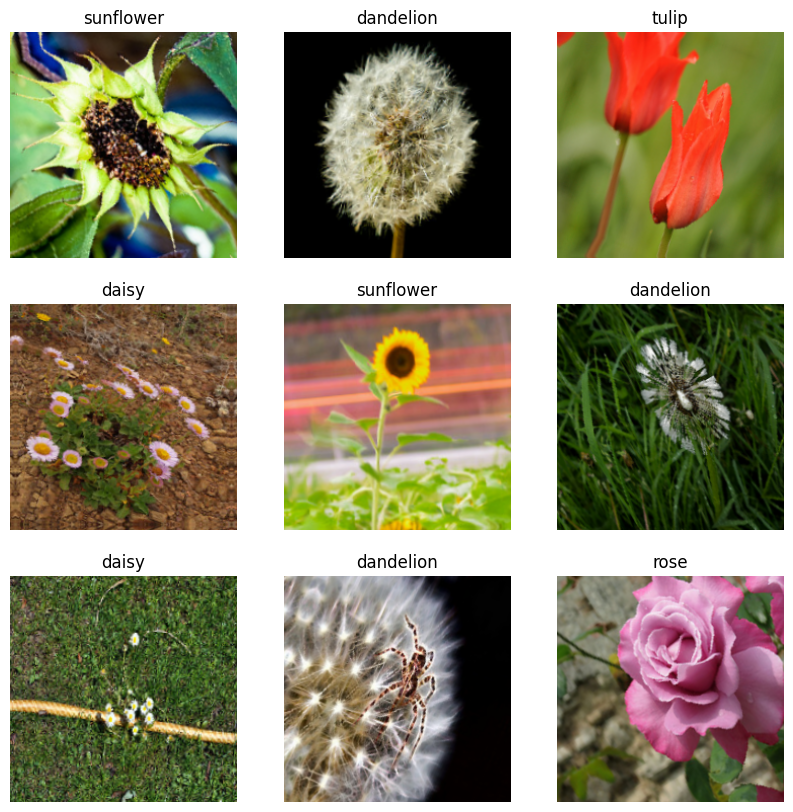

In [4]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2 # 20% of the training data will be used for validation
SEED = 42 # For reproducible split

# Load datasets from the 'train' directory and split into training and validation
train_ds = tf.keras.utils.image_dataset_from_directory(
    'dataset/Flower_Dataset/train',
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VALIDATION_SPLIT,
    subset='training'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'dataset/Flower_Dataset/train',
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VALIDATION_SPLIT,
    subset='validation'
)

# Get class names
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print(f"Found {train_ds.cardinality().numpy() * BATCH_SIZE} training images belonging to {NUM_CLASSES} classes.")
print(f"Found {val_ds.cardinality().numpy() * BATCH_SIZE} validation images belonging to {NUM_CLASSES} classes.")

# Data augmentation and normalization layers
data_augmentation = keras.Sequential(
    [
        layers.Rescaling(1./255),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

# Apply data augmentation and prepare datasets for performance
def prepare(ds, shuffle=False, augment=False):
    # Apply data augmentation
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    # Use buffered prefetching on all datasets to load images without blocking I/O
    return ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds = prepare(train_ds, augment=True)
val_ds = prepare(val_ds)

# Display some images for verification
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")
plt.show()

In [12]:
#@title Define the MLP block
class MLPBlock(layers.Layer):
    def __init__(self, hidden_units, dropout_rate, **kwargs):
        super().__init__(**kwargs)
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate

        self.dense_layers = []
        for units in hidden_units:
            self.dense_layers.append(layers.Dense(units, activation=tf.nn.gelu))
            self.dense_layers.append(layers.Dropout(dropout_rate))

    def call(self, inputs):
        x = inputs
        for layer in self.dense_layers:
            x = layer(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "hidden_units": self.hidden_units,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config

#@title Define the patch creation layer
class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "patch_size": self.patch_size,
            }
        )
        return config

#@title Implement the patch encoder
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim

        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "num_patches": self.num_patches,
                "projection_dim": self.projection_dim,
            }
        )
        return config

#@title Build the Vision Transformer model
def create_vit_classifier():
    # Model Hyperparameters - using global variables
    # image_size, patch_size, num_patches, projection_dim, num_heads,
    # transformer_layers, classifier_mlp_units, learning_rate, weight_decay, dropout_rate
    # are now global

    # MLP units for the transformer blocks (expand and project back to projection_dim)
    transformer_mlp_units = [projection_dim * 2, projection_dim]

    inputs = keras.Input(shape=(image_size, image_size, 3))

    # Create patches
    patches = Patches(patch_size)(inputs)

    # Encode patches
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    # The Transformer block consists of two main sub-layers: Multi-Head Self-Attention and a Feed-Forward Network.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = MLPBlock(transformer_mlp_units, dropout_rate)(x3) # Use transformer_mlp_units here
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(dropout_rate)(representation)

    # Add MLP head.
    features = MLPBlock(classifier_mlp_units, dropout_rate)(representation) # Use classifier_mlp_units here
    # Classify outputs.
    logits = layers.Dense(NUM_CLASSES, activation="softmax")(features) # Use softmax for multi-class classification

    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

In [14]:
# Model Hyperparameters - extracted to global variables for easier access/modification
# These were previously defined inside create_vit_classifier()
image_size = IMG_HEIGHT  # We'll use the same height and width for simplicity
patch_size = 16  # Size of the patches to be extracted from the images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_layers = 8
classifier_mlp_units = [2048, 1024]  # Size of the dense layers of the final classifier, renamed from mlp_head_units
learning_rate = 0.001
weight_decay = 0.0001
dropout_rate = 0.1

# Instantiate, compile and train the model

# Clear any old models from memory
keras.backend.clear_session()

# Create the Vision Transformer model
vit_model = create_vit_classifier()

# Configure the optimizer with weight decay
optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate, weight_decay=weight_decay
)

# Compile the model
vit_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False), # Use from_logits=False because the model outputs probabilities (softmax)
    metrics=['accuracy']
)

print("ViT model created and compiled successfully.")
vit_model.summary()

ViT model created and compiled successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 64)   │     61,760 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_block           │ (None, 196, 64)   │     16,576 │ layer_normalizat… │
│ (MLPBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ mlp_block[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_block_1         │ (None, 196, 64)   │     16,576 │ layer_normalizat… │
│ (MLPBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 196, 64)   │          0 │ mlp_block_1[0][0… │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat

 Total params: 28,522,949 (108.81 MB)

 Trainable params: 28,522,949 (108.81 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Define callbacks for early stopping and learning rate reduction
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001
)

# Train the model
history = vit_model.fit(
    train_ds,
    epochs=50, # You can adjust the number of epochs
    validation_data=val_ds,
    callbacks=[early_stopping, reduce_lr]
)

print("Model training complete.")

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step - accuracy: 0.2098 - loss: 5.8727 - val_accuracy: 0.1894 - val_loss: 1.6566 - learning_rate: 0.0010
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.2335 - loss: 1.6441 - val_accuracy: 0.1985 - val_loss: 1.5950 - learning_rate: 0.0010
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.2626 - loss: 1.5846 - val_accuracy: 0.2896 - val_loss: 1.5293 - learning_rate: 0.0010
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.2699 - loss: 1.5677 - val_accuracy: 0.2860 - val_loss: 1.5168 - learning_rate: 0.0010
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - accuracy: 0.2854 - loss: 1.5500 - val_accuracy: 0.2823 - val_loss: 1.5146 - learning_rate: 0.0010
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - accuracy: 0.3141 - loss: 1.5126 - val_accuracy: 0.2787 - val_loss: 1.4812 - learning_rate: 0.0010
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.3805 - loss: 1.4172 - val_acc

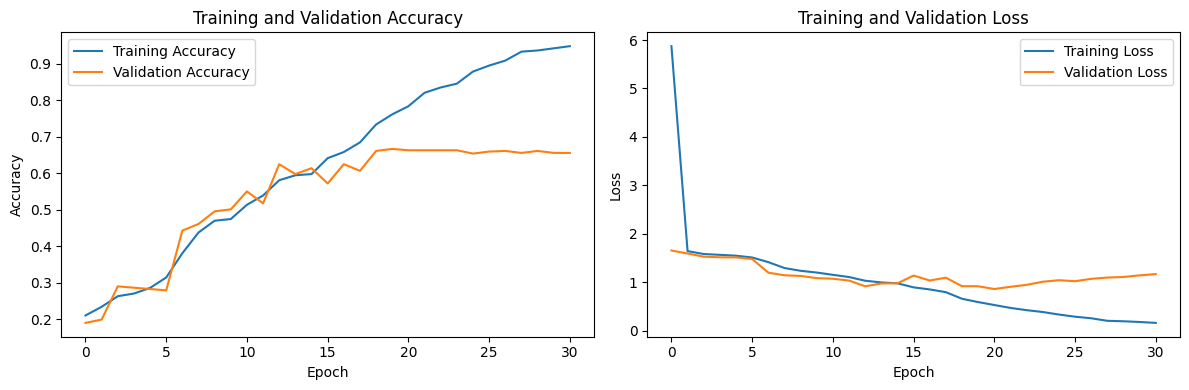

18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 812ms/step - accuracy: 0.6630 - loss: 0.8622
Validation Loss: 0.8622
Validation Accuracy: 0.6630


In [16]:
# Plot training history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the model on the validation set
loss, accuracy = vit_model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")